# 07221203_2025 dump 1 — why does `bstd_1000` have so many more high-`bstd` traces than `bstd`?

Series `07221203_2025`, dump `F0001`, **Detector 0 / Channel 0** (1517 traces). Follows
`07221203_2025_dump1_noise.ipynb`, where the 1000-sample baseline scatter had far more
high-`bstd` traces than the 500-sample one (for example 25% vs. 2% above `bstd = 32.48`).

Two ideas to test:

1. **Random pulses.** If pulses land at random positions in the 4096-sample trace, the chance of one
   in the pretrigger region should scale with the window length, 1000/4096 vs. 500/4096, only a factor
   of 2. (A pulse that starts earlier also has more time to raise the scatter, which would push the
   ratio above 2.)
2. **A change in the data.** At some point the dump could switch to triggered data whose trigger
   point sits somewhere between sample 500 and 1000.

Starting point: `bstd` and `bstd_1000` plotted against time. Events are numbered in time order
within a dump, so the event number is the time axis here. Uses the `python/` library
(`pulse_io`, `pulse_quantities.bstd` / `bstd_1000`). Run with the `darkmatter_cli_env` environment.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parents[1] / "python"))

from nsdf_dark_matter.idx import load_all_data

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

import pulse_io as pio
import pulse_quantities as pq

cdms = load_all_data(str(Path.home()) + '/idx/07221203_2025_F0001')

DETECTOR, CHANNEL = 0, 0
detector_id_arr, pulses = pio.load_channel_batch(
    cdms, pio.filter_by_detector(cdms.get_detector_ids(), DETECTOR), CHANNEL)

event = np.array([int(i.split('_')[0]) for i in detector_id_arr])
trigger = np.array([cdms.get_event_metadata(str(e)).trigger_type for e in event])   # from the dump's .csv
bstd_500 = pq.bstd(pulses)          # first 500 samples (leading glitch samples skipped)
bstd_1000 = pq.bstd_1000(pulses)    # first 1000 samples

print(f"{len(event)} traces, events {event.min()}-{event.max()}, in time order: {bool(np.all(np.diff(event) > 0))}")
print("trigger types:", {t: int((trigger == t).sum()) for t in np.unique(trigger)})

1517 traces, events 10000-11569, in time order: True
trigger types: {np.str_('Physics'): 1008, np.str_('Unknown'): 509}


## `bstd` and `bstd_1000` against event number

Grey bands mark events whose recorded trigger type is `Unknown` (the rest are `Physics`). Dashed line:
`bstd = 32.48`, the cap used in `07221203_2025_dump1_noise.ipynb`.

first Unknown-trigger event: 11000; 8 segments of Unknown events, lengths [57, 63, 72, 76, 72, 62, 58, 49]


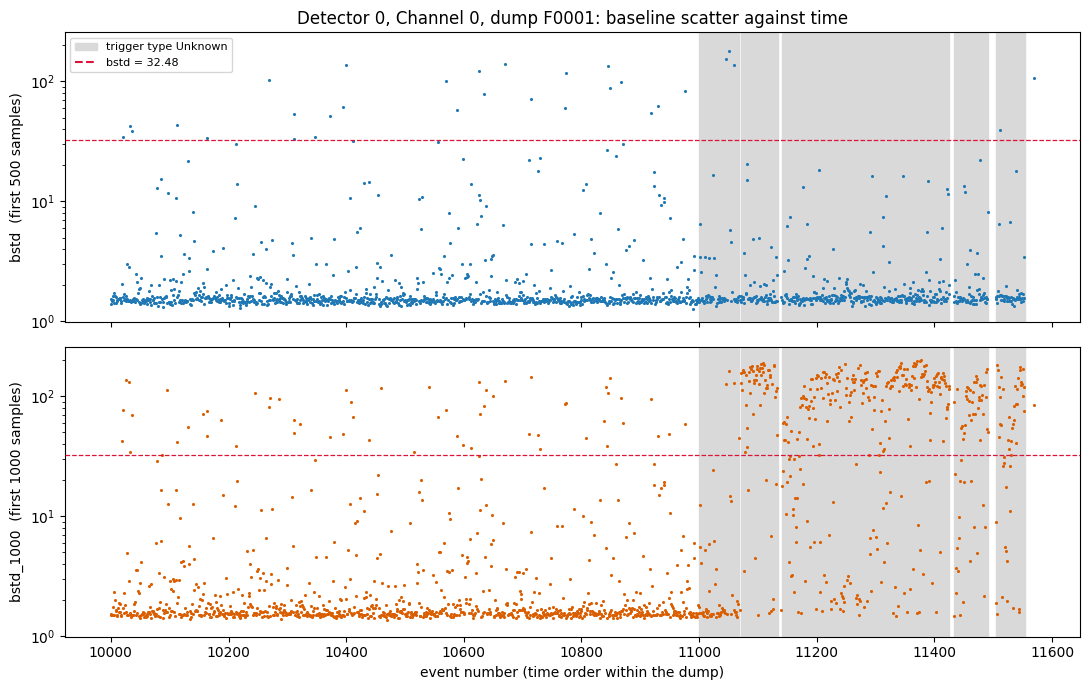

In [2]:
BSTD_CAP = 32.48

is_unknown = trigger == "Unknown"
first_unknown = int(event[is_unknown].min())
groups = np.split(np.arange(len(event)), np.flatnonzero(np.diff(is_unknown.astype(int))) + 1)
unknown_spans = [(event[g[0]], event[g[-1]]) for g in groups if is_unknown[g[0]]]
print(f"first Unknown-trigger event: {first_unknown}; {len(unknown_spans)} segments of Unknown events, "
      f"lengths {[len(g) for g in groups if is_unknown[g[0]]]}")

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True, sharey=True)
for ax, y, label, color in ((axes[0], bstd_500, "bstd  (first 500 samples)", "#1f77b4"),
                            (axes[1], bstd_1000, "bstd_1000  (first 1000 samples)", "#d95f02")):
    for lo, hi in unknown_spans:
        ax.axvspan(lo - 0.5, hi + 0.5, color="0.85", zorder=0)
    ax.scatter(event, y, s=5, color=color, linewidths=0, zorder=2)
    ax.axhline(BSTD_CAP, color="crimson", linestyle="--", linewidth=0.9, zorder=3)
    ax.set_yscale("log")
    ax.set_ylabel(label)

axes[0].set_title("Detector 0, Channel 0, dump F0001: baseline scatter against time")
axes[1].set_xlabel("event number (time order within the dump)")
axes[0].legend(handles=[Patch(color="0.85", label="trigger type Unknown"),
                        Line2D([0], [0], color="crimson", linestyle="--", label=f"bstd = {BSTD_CAP}")],
               loc="upper left", fontsize=8)
fig.tight_layout()
plt.show()

## How the high-`bstd` fraction differs between the two parts of the dump

Naive expectation for randomly placed pulses: the fraction with a pulse in the window scales with the
window length, so `bstd_1000` should exceed `bstd` by a factor of about 2 (1000/500).

In [3]:
regions = {
    f"events before {first_unknown} (all Physics)": event < first_unknown,
    f"from {first_unknown} on, trigger Unknown": (event >= first_unknown) & is_unknown,
    f"from {first_unknown} on, trigger Physics": (event >= first_unknown) & ~is_unknown,
    "all traces": np.ones(len(event), dtype=bool),
}

print(f"{'region':<38}{'traces':>7}  {'median bstd':>11} {'median bstd_1000':>17}  "
      f"{'% bstd>cap':>10} {'% bstd_1000>cap':>16} {'ratio':>6}")
for name, m in regions.items():
    f500, f1000 = 100 * (bstd_500[m] > BSTD_CAP).mean(), 100 * (bstd_1000[m] > BSTD_CAP).mean()
    ratio = f1000 / f500 if f500 > 0 else float("inf")
    print(f"{name:<38}{m.sum():>7}  {np.median(bstd_500[m]):>11.2f} {np.median(bstd_1000[m]):>17.2f}  "
          f"{f500:>10.1f} {f1000:>16.1f} {ratio:>6.1f}")
print(f"\nnaive random-placement expectation for the ratio: {1000 / 500:.1f}")

region                                 traces  median bstd  median bstd_1000  % bstd>cap  % bstd_1000>cap  ratio
events before 11000 (all Physics)        1000         1.53              1.61         2.7              5.9    2.2
from 11000 on, trigger Unknown            509         1.56             78.20         0.8             62.7   79.8
from 11000 on, trigger Physics              8         1.86              2.57        12.5             12.5    1.0
all traces                               1517         1.54              1.88         2.1             25.0   11.8

naive random-placement expectation for the ratio: 2.0


In [4]:
above = bstd_1000 > BSTD_CAP
print(f"traces with bstd_1000 > {BSTD_CAP}: {above.sum()} of {len(event)}; where they come from:")
for name, m in list(regions.items())[:3]:
    print(f"  {name:<38}{(above & m).sum():>5}  ({100 * (above & m).sum() / above.sum():.0f}% of them)")

ts = np.array([cdms.get_event_metadata(str(e)).global_timestamp for e in event])
print(f"\nglobal timestamps in the .csv: {len(np.unique(ts))} distinct values, from {ts[0]}  to  {ts[-1]}")

traces with bstd_1000 > 32.48: 379 of 1517; where they come from:
  events before 11000 (all Physics)        59  (16% of them)
  from 11000 on, trigger Unknown          319  (84% of them)
  from 11000 on, trigger Physics            1  (0% of them)

global timestamps in the .csv: 57 distinct values, from Sunday, December 04, 2022 02:25:47 AM UTC  to  Sunday, December 04, 2022 02:26:45 AM UTC


## The aligned pulses: Branch 2 high tail, `log10(ratio) >= 2.0`

In `07221203_2025_dump1_noise.ipynb` the Branch 2 high tail (500-sample window, `log10(ratio) >= 2.0`) shows
pulses that all start at nearly the same sample. Are they all from the `Unknown`-trigger part of the dump
(events from 11000 on)? The selection is repeated here with the library (`pulse_quantities`), same window and
same `dev > 0` requirement.

In [5]:
from dataclasses import replace
from pulse_config import DEFAULT_CONFIG

config_500 = replace(DEFAULT_CONFIG, pretrigger_samples=500)
dev_500 = pq.max_deviation(pulses, config_500)
log_ratio_500 = np.where(dev_500 > 0, pq.log_excursion_ratio(pulses, config_500), -np.inf)
bline_500 = pq.bline(pulses)

tail = log_ratio_500 >= 2.0
late = event >= first_unknown
print(f"high tail (log10(ratio) >= 2.0, 500-sample window): {tail.sum()} of {len(event)} traces")
print(f"  events before {first_unknown}:                 {(tail & ~late).sum():>4}")
print(f"  from {first_unknown} on, trigger Unknown:     {(tail & late & is_unknown).sum():>4}")
print(f"  from {first_unknown} on, trigger Physics:     {(tail & late & ~is_unknown).sum():>4}")
print(f"  event numbers of the tail traces: min {event[tail].min()}, max {event[tail].max()}")
print(f"\nfraction of each region in the high tail:")
for name, m in list(regions.items())[:3]:
    print(f"  {name:<38}{(tail & m).sum():>4} / {m.sum():<4} = {100 * (tail & m).sum() / m.sum():.1f}%")

high tail (log10(ratio) >= 2.0, 500-sample window): 346 of 1517 traces
  events before 11000:                   85
  from 11000 on, trigger Unknown:      260
  from 11000 on, trigger Physics:        1
  event numbers of the tail traces: min 10009, max 11552

fraction of each region in the high tail:
  events before 11000 (all Physics)       85 / 1000 = 8.5%
  from 11000 on, trigger Unknown         260 / 509  = 51.1%
  from 11000 on, trigger Physics           1 / 8    = 12.5%


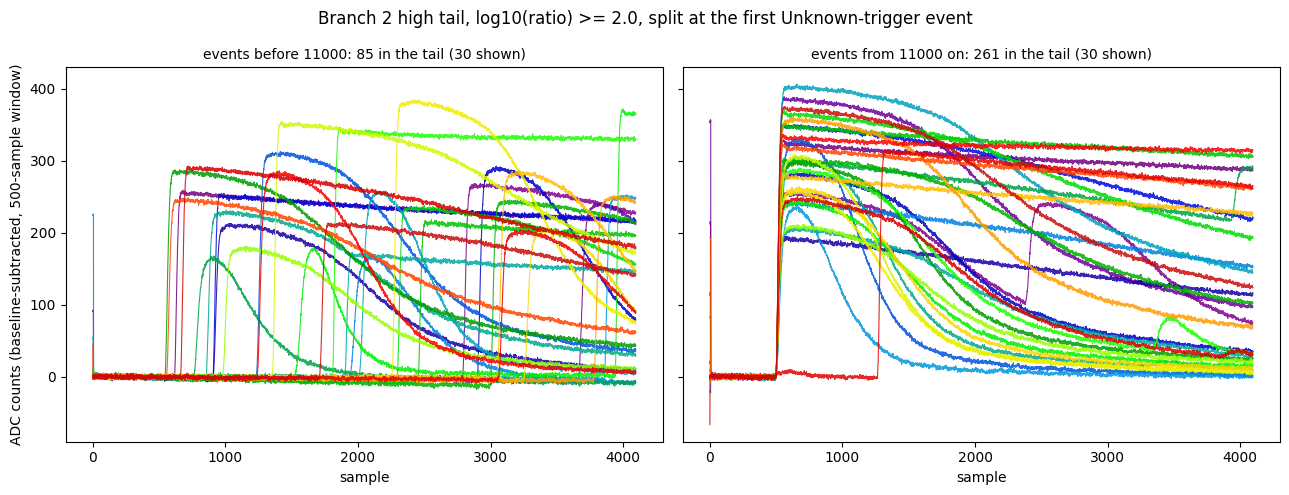

In [6]:
early_tail = np.flatnonzero(tail & ~late)
late_tail = np.flatnonzero(tail & late)
rng = np.random.default_rng(0)
show_early = rng.choice(early_tail, size=min(30, len(early_tail)), replace=False)
show_late = rng.choice(late_tail, size=min(30, len(late_tail)), replace=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
for ax, idx, title in ((axes[0], show_early, f"events before {first_unknown}: {len(early_tail)} in the tail"),
                       (axes[1], show_late, f"events from {first_unknown} on: {len(late_tail)} in the tail")):
    colors = plt.cm.nipy_spectral(np.linspace(0.05, 0.95, max(len(idx), 1)))
    for i, c in zip(idx, colors):
        ax.plot(pulses[i] - bline_500[i], linewidth=0.8, color=c, alpha=0.85)
    ax.set_title(f"{title} ({len(idx)} shown)", fontsize=10)
    ax.set_xlabel("sample")
axes[0].set_ylabel("ADC counts (baseline-subtracted, 500-sample window)")
fig.suptitle("Branch 2 high tail, log10(ratio) >= 2.0, split at the first Unknown-trigger event")
fig.tight_layout()
plt.show()

before 11000   n= 85  10%-crossing sample: min 511, median 2025, max 4038;  <= 520: 1
from 11000 on  n=261  10%-crossing sample: min 503, median 507, max 3771;  <= 520: 247
tail traces with the crossing at or before sample 520: 248 of 346


/var/folders/qs/y0dxxqrn4rd_pc96p6hnq51w0000gn/T/ipykernel_22721/3894139153.py:3: UserWarning: rise_sample is marked under_development: fraction=0.5 half-max crossing heuristic; only validated on one exploratory analysis (07221203_2025_dump1_noise.ipynb's Cut A rise-time check) -- not yet checked against noisy/multi-peak traces
  onset = np.asarray(pq.rise_sample(pulses[tail], config_500, fraction=0.1))


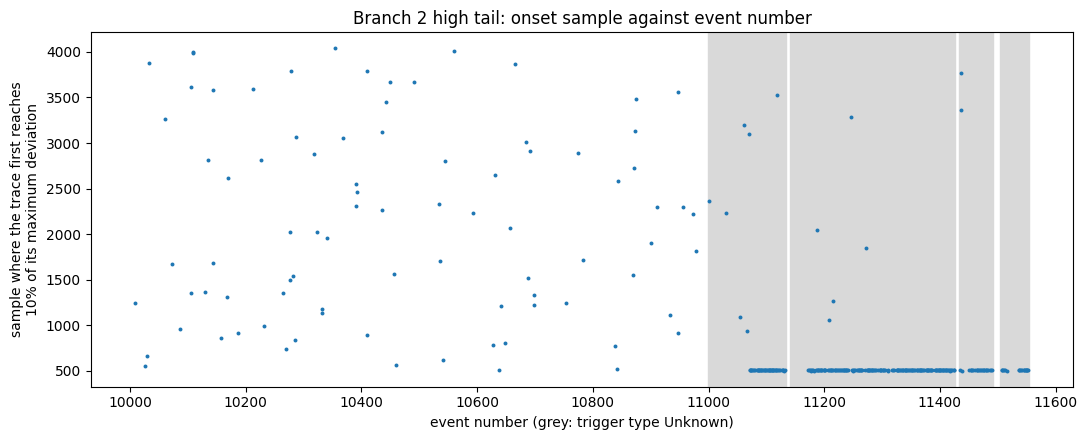

In [7]:
# where does each tail trace cross 10% of its own maximum deviation? (searched from sample 500 on, so a
# pulse that starts before 500 comes back as exactly 500)
onset = np.asarray(pq.rise_sample(pulses[tail], config_500, fraction=0.1))
ev_t = event[tail]
WINDOW = 520   # "aligned": reaches 10% of its maximum within 20 samples of the end of the 500-sample window
for name, m in (("before 11000", ev_t < first_unknown), ("from 11000 on", ev_t >= first_unknown)):
    o = onset[m]
    print(f"{name:<14} n={m.sum():>3}  10%-crossing sample: min {o.min()}, median {np.median(o):.0f}, "
          f"max {o.max()};  <= {WINDOW}: {(o <= WINDOW).sum()}")
print(f"tail traces with the crossing at or before sample {WINDOW}: {(onset <= WINDOW).sum()} of {len(onset)}")

fig, ax = plt.subplots(figsize=(11, 4.5))
for lo, hi in unknown_spans:
    ax.axvspan(lo - 0.5, hi + 0.5, color="0.85", zorder=0)
ax.scatter(ev_t, onset, s=8, color="#1f77b4", linewidths=0, zorder=2)
ax.set_xlabel("event number (grey: trigger type Unknown)")
ax.set_ylabel("sample where the trace first reaches\n10% of its maximum deviation")
ax.set_title("Branch 2 high tail: onset sample against event number")
fig.tight_layout()
plt.show()

In [8]:
# the Unknown segments one by one: bstd_1000, and how many traces are in the tail / aligned
aligned = np.zeros(len(event), dtype=bool)
aligned[np.flatnonzero(tail)[onset <= WINDOW]] = True
print(f"{'segment (events)':<18}{'traces':>7}{'med bstd_1000':>15}{'% > cap':>9}{'in tail':>9}{'aligned':>9}")
for lo, hi in unknown_spans:
    m = (event >= lo) & (event <= hi)
    print(f"{lo}-{hi:<12}{m.sum():>7}{np.median(bstd_1000[m]):>15.1f}{100 * (bstd_1000[m] > BSTD_CAP).mean():>9.0f}"
          f"{(tail & m).sum():>9}{(aligned & m).sum():>9}")
print(f"\nfirst aligned trace in the Unknown segments: event {event[aligned & is_unknown].min()};  last: event {event[aligned].max()}")
print(f"aligned traces outside the Unknown segments: {(aligned & ~is_unknown).sum()}  (events {event[aligned & ~is_unknown]})")
print(f"tail traces inside the Unknown segments that are NOT aligned: {(tail & is_unknown & ~aligned).sum()}")

segment (events)   traces  med bstd_1000  % > cap  in tail  aligned
11000-11067            57            1.6        7        5        0
11071-11133            63          135.1       83       47       46
11141-11212            72           43.5       56       28       26
11214-11289            76          100.8       64       49       46
11291-11362            72          115.1       71       41       41
11364-11425            62          122.6       84       44       44
11434-11491            58           70.6       67       27       25
11505-11553            49           58.5       65       19       19

first aligned trace in the Unknown segments: event 11071;  last: event 11552
aligned traces outside the Unknown segments: 1  (events [10637])
tail traces inside the Unknown segments that are NOT aligned: 13


## When do the `Unknown`-trigger traces rise?

`pq.half_max_time_us` is the time, in microseconds from the first sample of the trace (1.6 µs per sample), at which a
pulse first reaches 50% of its own maximum deviation. It is measured with the 500-sample window (the window has to
end before the pulse starts). It only means something for a trace that contains a pulse, so the histograms use
the Branch 2 high tail (`log10(ratio) >= 2.0`) as the "has a pulse" selection; for comparison the same is
shown for the `Physics` traces before event 11000. Sample 500 is at 800 µs.

/var/folders/qs/y0dxxqrn4rd_pc96p6hnq51w0000gn/T/ipykernel_22721/2091078417.py:1: UserWarning: half_max_time_us is marked under_development: built on rise_sample, which is still under development; meaningless for a trace with no pulse (it just finds the largest noise excursion)
  t_half = pq.half_max_time_us(pulses, config_500)      # microseconds, all traces
/Users/villaa/Research/NSDF-Data/python/pulse_quantities.py:185: UserWarning: rise_sample is marked under_development: fraction=0.5 half-max crossing heuristic; only validated on one exploratory analysis (07221203_2025_dump1_noise.ipynb's Cut A rise-time check) -- not yet checked against noisy/multi-peak traces
  return rise_sample(pulses, config, fraction=0.5) * config.sample_period_s * 1e6


Unknown-trigger traces in the high tail         n=260  10/50/90th pct:  827.2 /  836.0 /  852.8 us  (samples 517 / 522 / 533);  at or before 870 us: 246 = 95%
  ... excluding the first segment (to 11067)    n=255  10/50/90th pct:  827.2 /  835.2 /  849.0 us  (samples 517 / 522 / 531);  at or before 870 us: 246 = 96%
Physics traces before 11000 in the high tail    n= 85  10/50/90th pct: 1288.3 / 3345.6 / 6016.0 us  (samples 805 / 2091 / 3760);  at or before 870 us: 2 = 2%
Unknown-trigger traces not in the high tail: 249 of 509 (no pulse selected, not histogrammed)


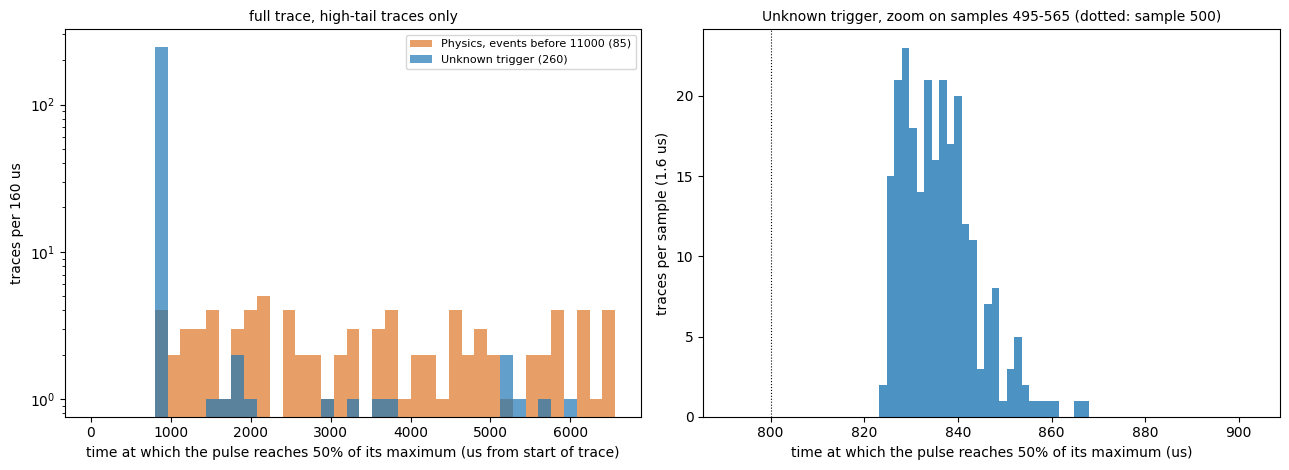

most common half-max samples among Unknown-trigger tail traces (sample: traces): {518: 23, 523: 21, 517: 21, 521: 21, 525: 20, 519: 18}


In [9]:
t_half = pq.half_max_time_us(pulses, config_500)      # microseconds, all traces
US = DEFAULT_CONFIG.sample_period_s * 1e6
unk_tail = tail & is_unknown
phys_tail = tail & ~late

def summarize(name, t):
    lo, med, hi = np.percentile(t, [10, 50, 90])
    near = (t <= 870).sum()
    print(f"{name:<47} n={len(t):>3}  10/50/90th pct: {lo:6.1f} / {med:6.1f} / {hi:6.1f} us  "
          f"(samples {lo / US:.0f} / {med / US:.0f} / {hi / US:.0f});  at or before 870 us: {near} = {100 * near / len(t):.0f}%")

summarize("Unknown-trigger traces in the high tail", t_half[unk_tail])
summarize("  ... excluding the first segment (to 11067)", t_half[unk_tail & (event > 11067)])
summarize("Physics traces before 11000 in the high tail", t_half[phys_tail])
print(f"Unknown-trigger traces not in the high tail: {(is_unknown & ~tail).sum()} of {is_unknown.sum()} (no pulse selected, not histogrammed)")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
ax = axes[0]
bins = np.arange(0, 4096 * US + 100 * US, 100 * US)
ax.hist(t_half[phys_tail], bins=bins, color="#d95f02", alpha=0.6, label=f"Physics, events before {first_unknown} ({phys_tail.sum()})")
ax.hist(t_half[unk_tail], bins=bins, color="#1f77b4", alpha=0.7, label=f"Unknown trigger ({unk_tail.sum()})")
ax.set_yscale("log")
ax.set_xlabel("time at which the pulse reaches 50% of its maximum (us from start of trace)")
ax.set_ylabel("traces per 160 us")
ax.set_title("full trace, high-tail traces only", fontsize=10)
ax.legend(fontsize=8)

ax = axes[1]
zbins = (np.arange(495, 566) - 0.5) * US
ax.hist(t_half[unk_tail], bins=zbins, color="#1f77b4", alpha=0.8)
ax.axvline(500 * US, color="k", linestyle=":", linewidth=0.8)
ax.set_xlabel("time at which the pulse reaches 50% of its maximum (us)")
ax.set_ylabel("traces per sample (1.6 us)")
ax.set_title("Unknown trigger, zoom on samples 495-565 (dotted: sample 500)", fontsize=10)
fig.tight_layout()
plt.show()

vals, counts = np.unique(np.round(t_half[unk_tail] / US).astype(int), return_counts=True)
top = np.argsort(counts)[::-1][:6]
print("most common half-max samples among Unknown-trigger tail traces (sample: traces):",
      {int(vals[i]): int(counts[i]) for i in top})

## The noise selection with and without the trigger cut

Working assumption from here on: the trigger types are labeled backwards, so events recorded as `Physics` are
**randoms** and events recorded as `Unknown` are **real triggers**. The library has the two cuts
`pulse_cuts.randoms` and `pulse_cuts.real_triggers`, which take the per-event trigger type
(`pulse_io.trigger_types`) instead of pulses.

The noise selection of Note 2 is the Tight band (`log10(ratio)` in [0.5, 0.7), 500-sample window, so `dev` is
measured only after sample 500) plus `log10(bstd) < 0.5`: 179 traces. Below it is compared with the same selection
**and** `randoms`.

In [10]:
trig = pio.trigger_types(cdms, detector_id_arr)          # same as the `trigger` array above, from the library
import pulse_cuts as pc
import pulse_operations as po

noise_sel = pc.excursion_band(pulses, config_500) & (np.log10(bstd_500) < 0.5)
sel_randoms = noise_sel & pc.randoms(trig)
sel_real = noise_sel & pc.real_triggers(trig)
assert np.array_equal(trig, trigger)
assert (sel_randoms | sel_real).sum() == noise_sel.sum()    # every selected trace is in one of the two

print(f"noise selection (Tight band + log10(bstd) < 0.5): {noise_sel.sum()} traces")
print(f"  and randoms (recorded Physics):      {sel_randoms.sum()}")
print(f"  and real_triggers (recorded Unknown): {sel_real.sum()}")
print(f"randoms in the selection:      events {event[sel_randoms].min()}-{event[sel_randoms].max()}; "
      f"{(sel_randoms & (event >= first_unknown)).sum()} of them after event {first_unknown}")
print(f"real triggers in the selection: events {event[sel_real].min()}-{event[sel_real].max()}")
print()
print(f"{'segment (events)':<18}{'traces':>7}{'in noise selection':>20}")
for lo, hi in unknown_spans:
    m = (event >= lo) & (event <= hi)
    print(f"{lo}-{hi:<12}{m.sum():>7}{(noise_sel & m).sum():>20}")
print(f"\nreal-trigger traces in the selection whose 500-sample window shows no pulse "
      f"(bstd_1000 < {BSTD_CAP}): {(sel_real & (bstd_1000 < BSTD_CAP)).sum()} of {sel_real.sum()}")

noise selection (Tight band + log10(bstd) < 0.5): 179 traces
  and randoms (recorded Physics):      141
  and real_triggers (recorded Unknown): 38
randoms in the selection:      events 10010-11433; 2 of them after event 11000
real triggers in the selection: events 11005-11544

segment (events)   traces  in noise selection
11000-11067            57                  15
11071-11133            63                   4
11141-11212            72                   1
11214-11289            76                   9
11291-11362            72                   2
11364-11425            62                   2
11434-11491            58                   2
11505-11553            49                   3

real-trigger traces in the selection whose 500-sample window shows no pulse (bstd_1000 < 32.48): 38 of 38


/var/folders/qs/y0dxxqrn4rd_pc96p6hnq51w0000gn/T/ipykernel_22721/1247934334.py:6: UserWarning: randoms is marked under_development: assumes the dump's trigger_type labels are swapped relative to their names: events recorded as 'Physics' are taken to be randoms (fixed-count random triggers) and 'Unknown' to be real triggers. That mapping is a working assumption from 07221203_2025_F0001 (see Note 2a), not confirmed against the DAQ configuration or the nsdf library
  sel_randoms = noise_sel & pc.randoms(trig)
/var/folders/qs/y0dxxqrn4rd_pc96p6hnq51w0000gn/T/ipykernel_22721/1247934334.py:7: UserWarning: real_triggers is marked under_development: the other half of the randoms assumption: events recorded as 'Unknown' are taken to be real (pulse-triggered) events. Not confirmed; see `randoms`
  sel_real = noise_sel & pc.real_triggers(trig)


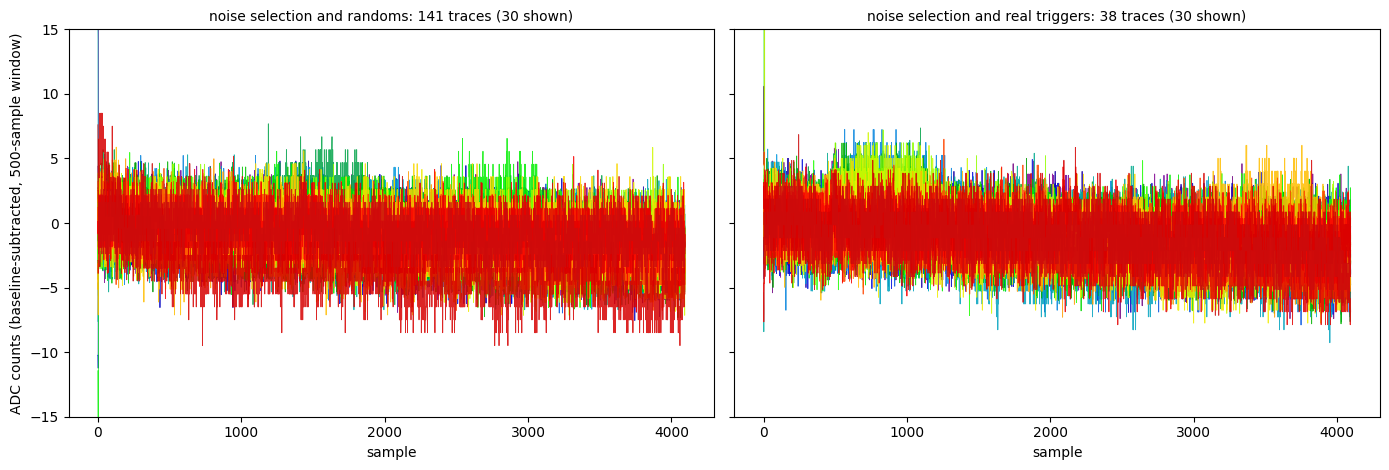

In [11]:
bl = pq.bline(pulses)
N_SHOW = 30
rng = np.random.default_rng(0)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharex=True, sharey=True)
for ax, m, title in ((axes[0], sel_randoms, f"noise selection and randoms: {sel_randoms.sum()} traces"),
                     (axes[1], sel_real, f"noise selection and real triggers: {sel_real.sum()} traces")):
    idx = rng.choice(np.flatnonzero(m), size=min(N_SHOW, m.sum()), replace=False)
    colors = plt.cm.nipy_spectral(np.linspace(0.05, 0.95, len(idx)))
    for i, c in zip(idx, colors):
        ax.plot(pulses[i] - bl[i], linewidth=0.6, color=c, alpha=0.85)
    ax.set_title(f"{title} ({len(idx)} shown)", fontsize=10)
    ax.set_xlabel("sample")
axes[0].set_ylabel("ADC counts (baseline-subtracted, 500-sample window)")
axes[0].set_ylim(-15, 15)   # zoomed on the noise: the leading glitch (up to ~350 counts in a few traces) runs off the top
fig.tight_layout()
plt.show()

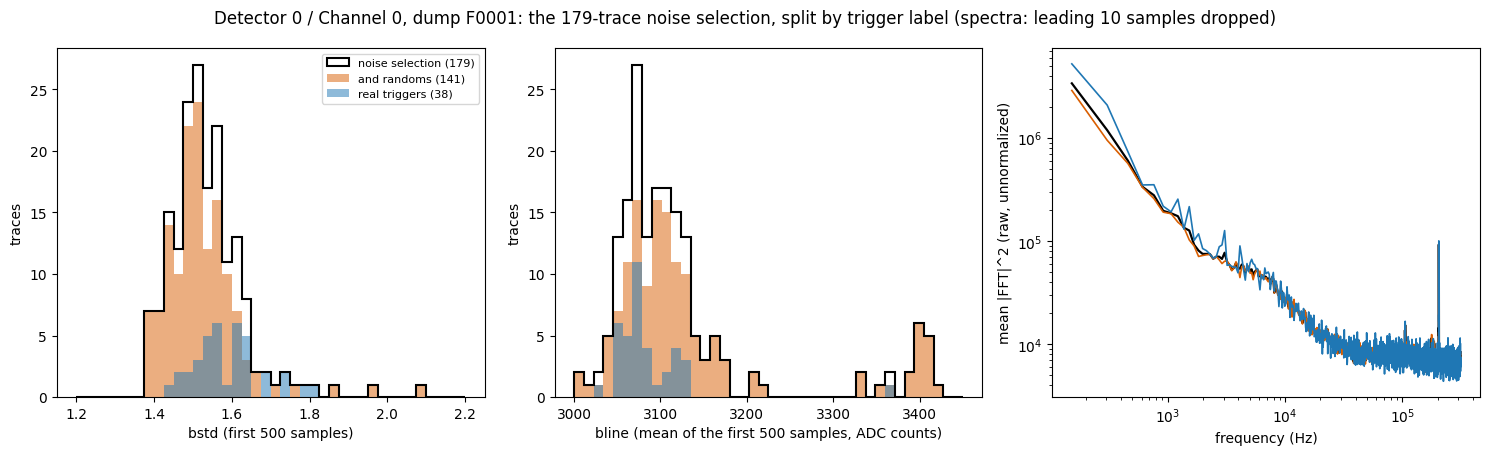

                                  bstd median (10-90%)  bline median  bline std
noise selection (179)            1.523 (1.436-1.644)        3099.5       98.2
and randoms (141)                1.513 (1.427-1.608)        3103.3      104.9
real triggers (38)               1.580 (1.489-1.727)        3073.1       53.2


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
groups = (("noise selection (179)", noise_sel, "k"),
          (f"and randoms ({sel_randoms.sum()})", sel_randoms, "#d95f02"),
          (f"real triggers ({sel_real.sum()})", sel_real, "#1f77b4"))

bins = np.linspace(1.2, 2.2, 41)
ax = axes[0]
for name, m, c in groups:
    ax.hist(bstd_500[m], bins=bins, histtype="step" if c == "k" else "stepfilled", alpha=1 if c == "k" else 0.5,
            color=c, label=name, linewidth=1.5 if c == "k" else 0)
ax.set_xlabel("bstd (first 500 samples)"); ax.set_ylabel("traces"); ax.legend(fontsize=8)

bl = pq.bline(pulses)
ax = axes[1]
bins = np.linspace(np.floor(bl[noise_sel].min() / 50) * 50, np.ceil(bl[noise_sel].max() / 50) * 50, 41)
for name, m, c in groups:
    ax.hist(bl[m], bins=bins, histtype="step" if c == "k" else "stepfilled", alpha=1 if c == "k" else 0.5,
            color=c, label=name, linewidth=1.5 if c == "k" else 0)
ax.set_xlabel("bline (mean of the first 500 samples, ADC counts)"); ax.set_ylabel("traces")

ax = axes[2]
flat = po.trim_glitch(po.baseline_subtract(pulses, config_500), config_500)   # drop the leading glitch samples
freqs = pq.frequencies_hz(flat.shape[-1], DEFAULT_CONFIG)
psd_mean = {}
for name, m, c in groups:
    psd_mean[name] = pq.power_spectrum(flat[m], DEFAULT_CONFIG).mean(axis=0)
    ax.loglog(freqs[1:], psd_mean[name][1:], color=c, label=name, linewidth=1.2 if c != "k" else 1.6)
ax.set_xlabel("frequency (Hz)"); ax.set_ylabel("mean |FFT|^2 (raw, unnormalized)")
fig.suptitle("Detector 0 / Channel 0, dump F0001: the 179-trace noise selection, split by trigger label (spectra: leading 10 samples dropped)")
fig.tight_layout()
plt.show()

print(f"{'':<28}{'bstd median (10-90%)':>26}{'bline median':>14}{'bline std':>11}")
for name, m, c in groups:
    lo, hi = np.percentile(bstd_500[m], [10, 90])
    print(f"{name:<28}{np.median(bstd_500[m]):>10.3f} ({lo:.3f}-{hi:.3f}){np.median(bl[m]):>14.1f}{bl[m].std():>11.1f}")

In [13]:
# Trigger label and time are tangled: nearly all randoms are before event 11000 and all real triggers after it.
# Split the real triggers at the end of the first Unknown segment, and look at band-averaged raw |FFT|^2.
early_randoms = sel_randoms & (event < first_unknown)
real_seg1 = sel_real & (event <= unknown_spans[0][1])
real_later = sel_real & (event > unknown_spans[0][1])
P = pq.power_spectrum(flat, DEFAULT_CONFIG)
bands = [(1e3, 3e3), (3e3, 1e4), (1e4, 5e4), (5e4, 1.5e5), (2.5e5, 3.1e5)]
print(f"{'band (Hz)':<16}{'randoms <11000':>16}{'real, segment 1':>17}{'real, later':>13}{'later / randoms':>17}{'seg 1 / randoms':>17}")
print(f"{'traces':<16}{early_randoms.sum():>16}{real_seg1.sum():>17}{real_later.sum():>13}")
for lo, hi in bands:
    k = (freqs >= lo) & (freqs < hi)
    a, s1, s2 = (P[m][:, k].mean() for m in (early_randoms, real_seg1, real_later))
    print(f"{lo:>7.0f}-{hi:<8.0f}{a:>16.3g}{s1:>17.3g}{s2:>13.3g}{s2 / a:>17.2f}{s1 / a:>17.2f}")

k = np.argmin(np.abs(freqs - 204e3))
print(f"\nline near {freqs[k] / 1e3:.0f} kHz: mean |FFT|^2 in that bin / in bins 7-8 away on each side")
for name, m in (("randoms < 11000", early_randoms), ("real, segment 1", real_seg1), ("real, later", real_later)):
    print(f"  {name:<18}{P[m][:, k].mean():>10.3g} / {P[m][:, [k - 8, k - 7, k + 7, k + 8]].mean():.3g}")

print(f"\nbline above 3300: randoms {(sel_randoms & (bl > 3300)).sum()} of {sel_randoms.sum()}, "
      f"real triggers {(sel_real & (bl > 3300)).sum()} of {sel_real.sum()} (real-trigger range {bl[sel_real].min():.0f}-{bl[sel_real].max():.0f})")

band (Hz)         randoms <11000  real, segment 1  real, later  later / randoms  seg 1 / randoms
traces                       139               15           23
   1000-3000            9.28e+04         8.56e+04     1.43e+05             1.54             0.92
   3000-10000            4.4e+04         4.45e+04     5.08e+04             1.16             1.01
  10000-50000           1.16e+04         1.17e+04     1.16e+04             1.00             1.01
  50000-150000          7.83e+03         7.86e+03     7.87e+03             1.01             1.00
 250000-310000          6.79e+03         6.75e+03     6.79e+03             1.00             0.99

line near 204 kHz: mean |FFT|^2 in that bin / in bins 7-8 away on each side
  randoms < 11000     8.97e+04 / 7.82e+03
  real, segment 1      9.1e+04 / 7.02e+03
  real, later         1.06e+05 / 6.1e+03

bline above 3300: randoms 18 of 141, real triggers 1 of 38 (real-trigger range 3030-3371)


### The mean spectrum is dominated by a few leading-glitch traces

An earlier version of this analysis took the spectra from the whole trace and found less power between 1 and 60 kHz
in the real triggers. The mean and the median of the per-trace power in that band disagree strongly for the randoms,
which points at a few traces. The leading samples (0 to 9) are skipped by `bstd` and `bline`, but not by an FFT.

mean and median of the per-trace 10-50 kHz power
              whole trace: mean    median    leading 10 dropped: mean    median
randoms                1.14e+05   1.2e+04                    1.16e+04  1.16e+04
real                   3.92e+04   1.2e+04                    1.16e+04  1.15e+04



largest |sample| among the first 10 samples (counts): randoms median 3.2, max 354; real median 3.1, max 170
randoms with 10-50 kHz power above 10x the selection median: 6 (events [10176 10185 10470 10517 10807 10971]), real triggers: 1


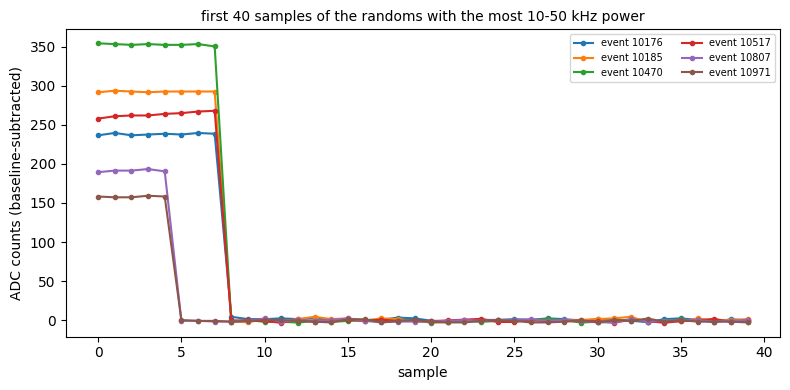

In [14]:
P_full = pq.power_spectrum(po.baseline_subtract(pulses, config_500), DEFAULT_CONFIG)      # whole trace, glitch samples kept
f_full = pq.frequencies_hz(pulses.shape[-1], DEFAULT_CONFIG)
P_trim = pq.power_spectrum(flat, DEFAULT_CONFIG)                                         # leading 10 samples dropped
band_full = P_full[:, (f_full >= 1e4) & (f_full < 5e4)].mean(axis=1)
band_trim = P_trim[:, (freqs >= 1e4) & (freqs < 5e4)].mean(axis=1)

print("mean and median of the per-trace 10-50 kHz power")
print(f"{'':<12}{'whole trace: mean':>19}{'median':>10}{'   leading 10 dropped: mean':>28}{'median':>10}")
for name, m in (("randoms", sel_randoms), ("real", sel_real)):
    print(f"{name:<12}{band_full[m].mean():>19.3g}{np.median(band_full[m]):>10.3g}{band_trim[m].mean():>28.3g}{np.median(band_trim[m]):>10.3g}")

lead = np.abs(po.baseline_subtract(pulses, config_500)[:, :DEFAULT_CONFIG.glitch_samples]).max(axis=1)
print(f"\nlargest |sample| among the first {DEFAULT_CONFIG.glitch_samples} samples (counts): "
      f"randoms median {np.median(lead[sel_randoms]):.1f}, max {lead[sel_randoms].max():.0f}; "
      f"real median {np.median(lead[sel_real]):.1f}, max {lead[sel_real].max():.0f}")
big = np.flatnonzero(sel_randoms & (band_full > 10 * np.median(band_full[noise_sel])))
print(f"randoms with 10-50 kHz power above 10x the selection median: {len(big)} (events {event[big]}), "
      f"real triggers: {(sel_real & (band_full > 10 * np.median(band_full[noise_sel]))).sum()}")

fig, ax = plt.subplots(figsize=(8, 4))
x0 = po.baseline_subtract(pulses, config_500)
for i in big:
    ax.plot(np.arange(40), x0[i, :40], marker=".", label=f"event {event[i]}")
ax.set_xlabel("sample"); ax.set_ylabel("ADC counts (baseline-subtracted)")
ax.set_title("first 40 samples of the randoms with the most 10-50 kHz power", fontsize=10)
ax.legend(fontsize=7, ncol=2)
fig.tight_layout()
plt.show()